In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from pathlib import Path

from src.preprocessing import preprocess_tabular

In [ ]:
os.chdir("/home/yogeshwar10/Data Science Projects/satellite-property-valuation")

In [58]:
df_train_raw = pd.read_csv(r"data/raw/train.csv")
df_test_raw = pd.read_csv(r"data/raw/test.csv")

In [59]:
df_train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             16209 non-null  int64  
 1   date           16209 non-null  object 
 2   price          16209 non-null  int64  
 3   bedrooms       16209 non-null  int64  
 4   bathrooms      16209 non-null  float64
 5   sqft_living    16209 non-null  int64  
 6   sqft_lot       16209 non-null  int64  
 7   floors         16209 non-null  float64
 8   waterfront     16209 non-null  int64  
 9   view           16209 non-null  int64  
 10  condition      16209 non-null  int64  
 11  grade          16209 non-null  int64  
 12  sqft_above     16209 non-null  int64  
 13  sqft_basement  16209 non-null  int64  
 14  yr_built       16209 non-null  int64  
 15  yr_renovated   16209 non-null  int64  
 16  zipcode        16209 non-null  int64  
 17  lat            16209 non-null  float64
 18  long  

In [60]:
df_train_raw.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


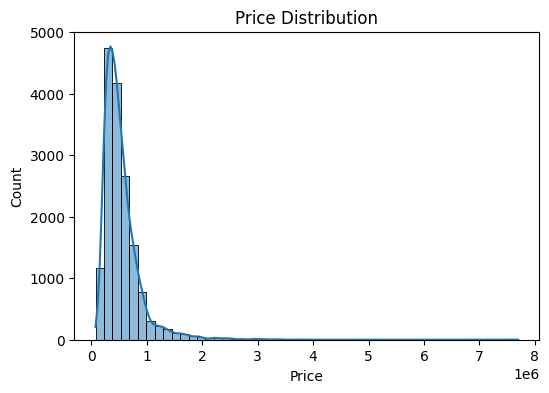

In [61]:
plt.figure(figsize=(6,4))
sns.histplot(df_train_raw["price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

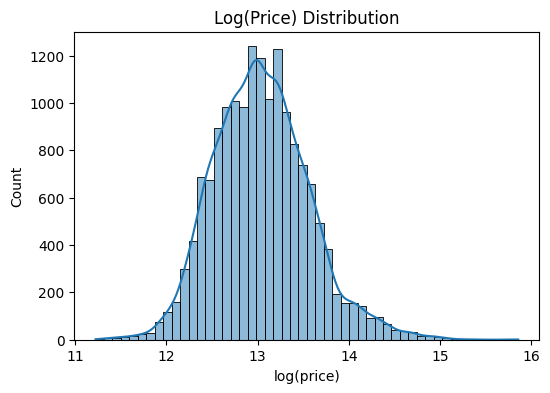

In [62]:
plt.figure(figsize=(6,4))
sns.histplot(np.log(df_train_raw["price"]), bins=50, kde=True)
plt.title("Log(Price) Distribution")
plt.xlabel("log(price)")
plt.ylabel("Count")
plt.show()

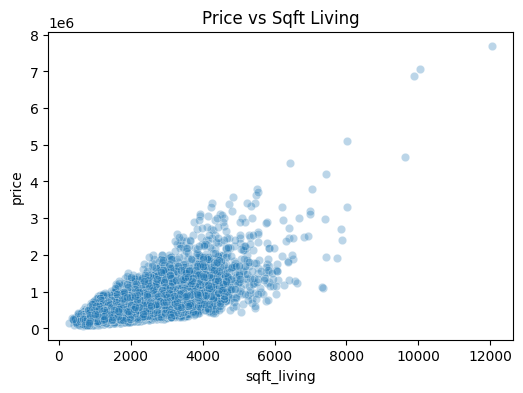

In [63]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df_train_raw["sqft_living"], y=df_train_raw["price"], alpha=0.3)
plt.title("Price vs Sqft Living")
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.show()

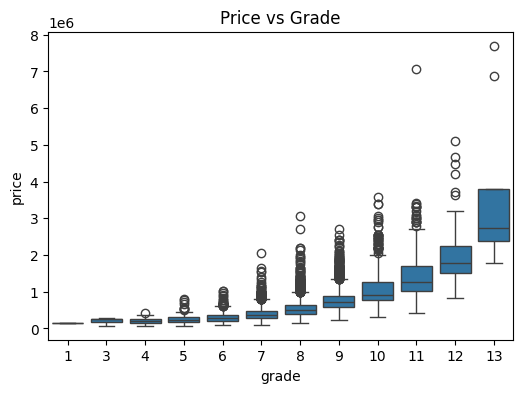

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_train_raw["grade"], y=df_train_raw["price"])
plt.title("Price vs Grade")
plt.xlabel("grade")
plt.ylabel("price")
plt.show()


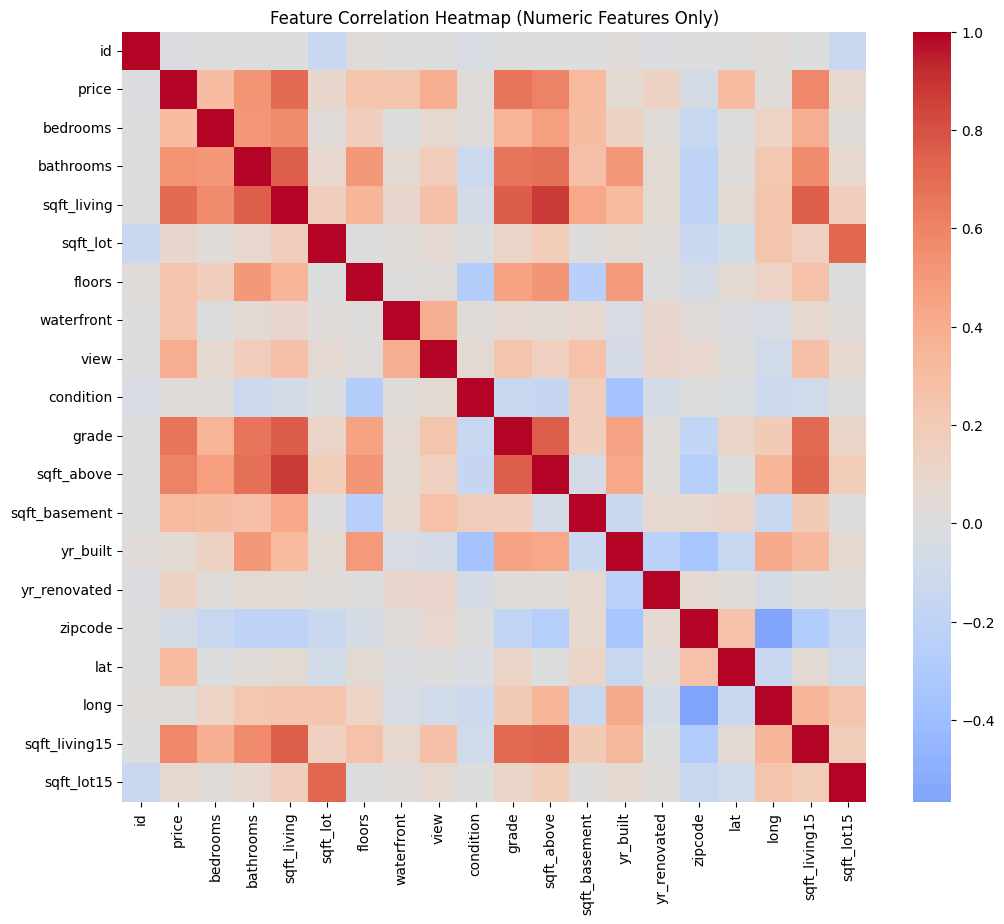

In [65]:
plt.figure(figsize=(12,10))
numeric_df = df_train_raw.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (Numeric Features Only)")
plt.show()


In [66]:
df_train_proc = preprocess_tabular(df_train_raw, is_train=True)
df_test_proc  = preprocess_tabular(df_test_raw, is_train=False)

In [67]:
assert "log_price" in df_train_proc.columns
assert "log_price" not in df_test_proc.columns
assert df_train_proc.shape[1] == df_test_proc.shape[1] + 2

In [68]:
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(exist_ok=True)

df_train_proc.to_csv(OUT_DIR / "train_tabular_processed.csv", index=False)
df_test_proc.to_csv(OUT_DIR / "test_tabular_processed.csv", index=False)